# Linear Regression on the Brainvita Dataset (From Scratch)

This notebook demonstrates your custom `rice_ml` implementation of **Ordinary Least Squares (OLS)** on the Brainvita board-state dataset.

The goal is not only to train a model, but to clearly connect:

1. **Theory** (linear model + least-squares objective)
2. **Implementation** (your `LinearRegression` class)
3. **Interpretation** (metrics, residuals, coefficient meaning)

By the end, this notebook gives a complete baseline regression narrative that we can compare against more expressive models (trees, ensembles, MLP) later.


## 1. Mathematical Intuition

Linear regression assumes a linear relationship between features and target:

$$
\hat{y} = X\beta + \epsilon
$$

- $X$ is the feature matrix
- $\beta$ is the coefficient vector (plus an intercept if enabled)
- $\epsilon$ is residual error

OLS chooses parameters that minimize squared prediction error:

$$
\min_{\beta} \; \|y - X\beta\|_2^2
$$

Setting the gradient to zero yields the normal-equation solution:

$$
\beta^* = (X^T X)^{-1} X^T y
$$

Your implementation uses the **Moore-Penrose pseudo-inverse** (`pinv`) for numerical stability when $X^T X$ is singular or ill-conditioned.


In [1]:
from pathlib import Path
import sys
import csv

import numpy as np
import matplotlib.pyplot as plt


def find_repo_root(start='.'):
    p = Path(start).resolve()
    for q in [p, *p.parents]:
        if (q / 'src' / 'rice_ml').exists() and (q / 'data' / 'brainvita_dataset.csv').exists():
            return q
    raise FileNotFoundError('Could not locate repository root')


ROOT = find_repo_root('.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from rice_ml.supervised_learning import LinearRegression

DATA_PATH = ROOT / 'data' / 'brainvita_dataset.csv'
print('Repo root:', ROOT)
print('Dataset path:', DATA_PATH)


Repo root: /Users/LakshSarda/Desktop/CMOR_438_Repository
Dataset path: /Users/LakshSarda/Desktop/CMOR_438_Repository/data/brainvita_dataset.csv


## 2. Load Data and Define Features

We predict:

- **Target:** `num_legal_moves`

Feature policy for readable OLS interpretation:

- Start from engineered board-state summaries
- Exclude action-output and raw board serialization fields
- Prefer a **non-redundant subset** of features to reduce structural multicollinearity

This keeps the coefficient story interpretable instead of dominated by algebraic dependencies.


In [2]:
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    header = f.readline().strip().split(',')

print(f'Total columns in dataset: {len(header)}')

target_col = 'num_legal_moves'
exclude_cols = {
    target_col,
    'board_state',
    'best_move_r1', 'best_move_c1', 'best_move_r2', 'best_move_c2',
    'worst_move_r1', 'worst_move_c1', 'worst_move_r2', 'worst_move_c2',
}

raw_feature_cols = [c for c in header if c not in exclude_cols]
selected_cols = raw_feature_cols + [target_col]
selected_idx = [header.index(c) for c in selected_cols]

arr = np.loadtxt(DATA_PATH, delimiter=',', skiprows=1, usecols=selected_idx, dtype=float)
X_raw = arr[:, :-1]
y = arr[:, -1]

# Curated feature subset to reduce structural multicollinearity.
preferred_features = [
    'peg_ratio',
    'jumpable_pegs',
    'mobility_ratio',
    'num_clusters',
    'largest_cluster',
    'avg_adjacent_pegs',
    'avg_adjacent_empty',
    'max_adjacent_empty',
    'center_of_mass_r',
    'center_of_mass_c',
    'spread',
    'min_pegs_reachable',
    'max_pegs_reachable',
    'board_rows',
    'board_cols',
]

feature_cols = [c for c in preferred_features if c in raw_feature_cols]
keep_idx = [raw_feature_cols.index(c) for c in feature_cols]
X = X_raw[:, keep_idx]

print(f'Rows: {X.shape[0]:,}')
print(f'Raw candidate features: {len(raw_feature_cols)}')
print(f'Final curated features: {len(feature_cols)}')
print('Features used:', feature_cols)
print('Target min/mean/max: %.3f / %.3f / %.3f' % (float(y.min()), float(y.mean()), float(y.max())))


Total columns in dataset: 32


Rows: 238,486
Raw candidate features: 22
Final curated features: 15
Features used: ['peg_ratio', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster', 'avg_adjacent_pegs', 'avg_adjacent_empty', 'max_adjacent_empty', 'center_of_mass_r', 'center_of_mass_c', 'spread', 'min_pegs_reachable', 'max_pegs_reachable', 'board_rows', 'board_cols']
Target min/mean/max: 1.000 / 2.080 / 10.000


## 3. Exploratory Data Analysis

Before fitting, we inspect:

- the target distribution
- strongest linear associations with the target

This helps validate whether a linear baseline is sensible and which features are likely to drive predictions.


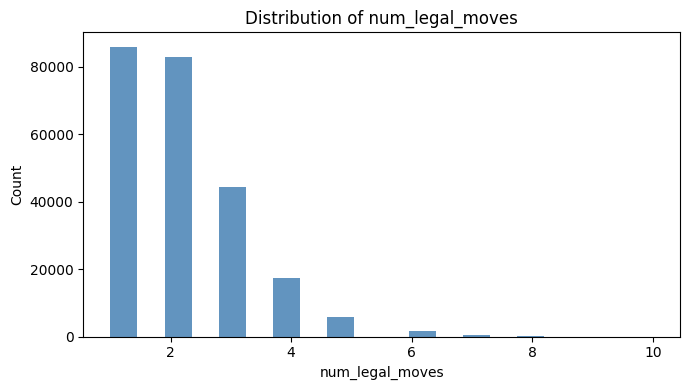

Top feature correlations with num_legal_moves:
         jumpable_pegs :  0.9465
        mobility_ratio :  0.6668
    max_pegs_reachable :  0.3478
    min_pegs_reachable : -0.3433
       largest_cluster :  0.2584
            board_rows :  0.2360
            board_cols :  0.2329
      center_of_mass_r :  0.1942
      center_of_mass_c :  0.1937
     avg_adjacent_pegs :  0.1867
                spread :  0.1712
    max_adjacent_empty :  0.1593


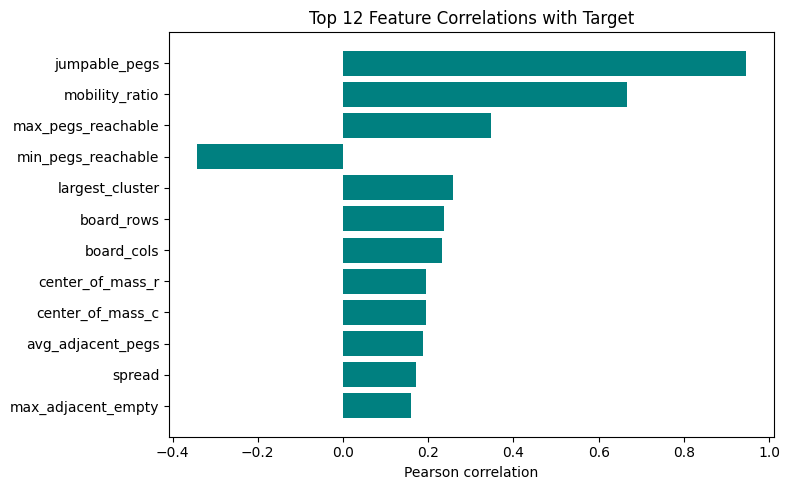

In [3]:
# Target distribution
plt.figure(figsize=(7, 4))
plt.hist(y, bins=20, color='steelblue', alpha=0.85)
plt.title('Distribution of num_legal_moves')
plt.xlabel('num_legal_moves')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Correlation with target
Xy = np.column_stack([X, y])
corr = np.corrcoef(Xy, rowvar=False)
corr_target = corr[:-1, -1]
order = np.argsort(np.abs(corr_target))[::-1]

print('Top feature correlations with num_legal_moves:')
for i in order[:12]:
    print(f'{feature_cols[i]:>22s} : {corr_target[i]: .4f}')

# Horizontal bar chart (top 12)
top_idx = order[:12][::-1]
plt.figure(figsize=(8, 5))
plt.barh([feature_cols[i] for i in top_idx], [corr_target[i] for i in top_idx], color='teal')
plt.title('Top 12 Feature Correlations with Target')
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()


## 4. Preprocessing and Train/Test Split

Pipeline:

1. Random **80/20** split (seeded for reproducibility)
2. Use a curated non-redundant feature set
3. Standardize features using **training-set** mean/std only

Why this matters:

- Improves coefficient stability and readability
- Reduces multicollinearity artifacts in OLS estimates
- Preserves leakage safety by fitting scaling only on train data


In [4]:
rng = np.random.default_rng(42)
idx = np.arange(X.shape[0])
rng.shuffle(idx)

split = int(0.8 * len(idx))
train_idx, test_idx = idx[:split], idx[split:]

X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)
sigma_safe = np.where(sigma < 1e-12, 1.0, sigma)

X_train = (X_train_raw - mu) / sigma_safe
X_test = (X_test_raw - mu) / sigma_safe

print('Split summary')
print('-' * 44)
print(f'Train samples: {X_train.shape[0]:,}')
print(f'Test samples : {X_test.shape[0]:,}')
print(f'Features used: {X_train.shape[1]}')
print('-' * 44)


Split summary
--------------------------------------------
Train samples: 190,788
Test samples : 47,698
Features used: 15
--------------------------------------------


## 5. Fit the Custom Linear Regression Model

We train `LinearRegression(fit_intercept=True)` from your package and present a compact model summary (instead of raw debug-style array dumps).


In [5]:
model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)

coef = model.coef_

print('Model summary')
print('-' * 60)
print(f'Estimator        : {model}')
print(f'Intercept        : {model.intercept_:.6f}')
print(f'n_features_in_   : {model.n_features_in_}')
print(f'||coef||_2       : {np.linalg.norm(coef):.6f}')
print(f'max |coef|       : {np.max(np.abs(coef)):.6f}')
print('-' * 60)


Model summary
------------------------------------------------------------
Estimator        : LinearRegression(fit_intercept=True)
Intercept        : 2.081090
n_features_in_   : 15
||coef||_2       : 0.866980
max |coef|       : 0.766806
------------------------------------------------------------


## 6. Evaluate Performance

We report:

- **R²**: proportion of variance explained
- **MSE / RMSE**: squared-error scale
- **MAE**: average absolute prediction error

We also compare against a naive baseline that predicts the training-mean target for every test sample.


In [6]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = float(np.mean((y_true - y_pred) ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
    return r2, mse, rmse, mae


y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

train_r2, train_mse, train_rmse, train_mae = regression_metrics(y_train, y_pred_train)
test_r2, test_mse, test_rmse, test_mae = regression_metrics(y_test, y_pred_test)

baseline_pred = np.full_like(y_test, fill_value=float(y_train.mean()), dtype=float)
base_r2, base_mse, base_rmse, base_mae = regression_metrics(y_test, baseline_pred)

rows = [
    ('Train', train_r2, train_mse, train_rmse, train_mae),
    ('Test', test_r2, test_mse, test_rmse, test_mae),
    ('Baseline (mean predictor)', base_r2, base_mse, base_rmse, base_mae),
]

print('Performance summary')
print('-' * 86)
print(f"{'Split':<28} {'R2':>10} {'MSE':>14} {'RMSE':>14} {'MAE':>14}")
print('-' * 86)
for name, r2, mse, rmse, mae in rows:
    print(f"{name:<28} {r2:>10.4f} {mse:>14.4f} {rmse:>14.4f} {mae:>14.4f}")
print('-' * 86)


Performance summary
--------------------------------------------------------------------------------------
Split                                R2            MSE           RMSE            MAE
--------------------------------------------------------------------------------------
Train                            0.9464         0.0647         0.2544         0.1755
Test                             0.9458         0.0643         0.2537         0.1764
Baseline (mean predictor)       -0.0000         1.1863         1.0892         0.8302
--------------------------------------------------------------------------------------


## 7. Diagnostic Visuals

We use three standard diagnostics:

1. **Predicted vs Actual**: closeness to identity line
2. **Residuals vs Predicted**: structure that may indicate misspecification
3. **Residual histogram**: central tendency and spread of error

Then we inspect top standardized coefficients for interpretability.


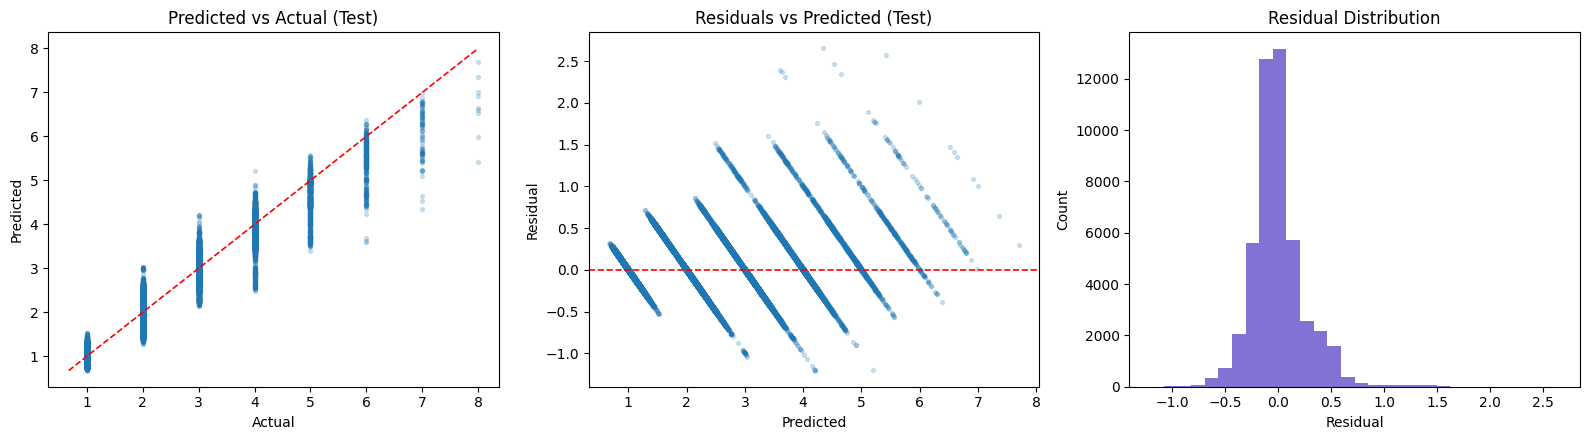

In [7]:
residuals_test = y_test - y_pred_test

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

ax[0].scatter(y_test, y_pred_test, alpha=0.2, s=8)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax[0].plot(lims, lims, 'r--', linewidth=1.2)
ax[0].set_title('Predicted vs Actual (Test)')
ax[0].set_xlabel('Actual')
ax[0].set_ylabel('Predicted')

ax[1].scatter(y_pred_test, residuals_test, alpha=0.2, s=8)
ax[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
ax[1].set_title('Residuals vs Predicted (Test)')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Residual')

ax[2].hist(residuals_test, bins=30, color='slateblue', alpha=0.85)
ax[2].set_title('Residual Distribution')
ax[2].set_xlabel('Residual')
ax[2].set_ylabel('Count')

plt.tight_layout()
plt.show()


Top coefficients by absolute magnitude
------------------------------------------------------------------------------
Rank   Feature                             Coefficient      |Coefficient|
------------------------------------------------------------------------------
1      jumpable_pegs                          0.766806           0.766806
2      mobility_ratio                         0.344314           0.344314
3      max_adjacent_empty                     0.131831           0.131831
4      avg_adjacent_pegs                      0.097543           0.097543
5      peg_ratio                              0.092926           0.092926
6      max_pegs_reachable                     0.068823           0.068823
7      board_rows                             0.041114           0.041114
8      board_cols                             0.040064           0.040064
9      num_clusters                           0.030312           0.030312
10     avg_adjacent_empty                     0.020833         

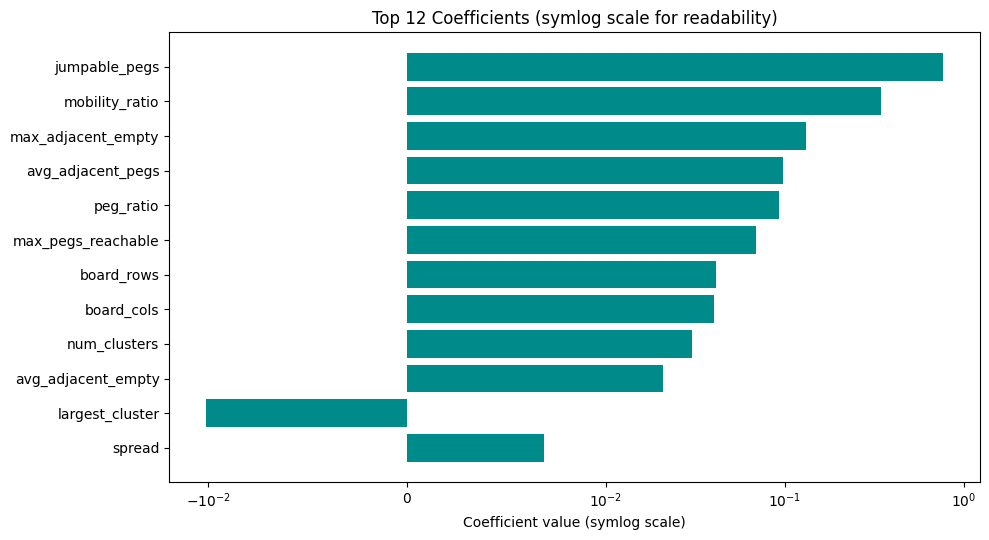

In [8]:
coef = model.coef_
abs_coef = np.abs(coef)
order_coef = np.argsort(abs_coef)[::-1]

print('Top coefficients by absolute magnitude')
print('-' * 78)
print(f"{'Rank':<6} {'Feature':<28} {'Coefficient':>18} {'|Coefficient|':>18}")
print('-' * 78)
for rank, i in enumerate(order_coef[:12], start=1):
    print(f"{rank:<6} {feature_cols[i]:<28} {coef[i]:>18.6f} {abs_coef[i]:>18.6f}")
print('-' * 78)

show = order_coef[:12][::-1]
vals = coef[show]
labels = [feature_cols[i] for i in show]

plt.figure(figsize=(10, 5.5))
plt.barh(labels, vals, color='darkcyan')
plt.xscale('symlog', linthresh=1e-2)
plt.title('Top 12 Coefficients (symlog scale for readability)')
plt.xlabel('Coefficient value (symlog scale)')
plt.tight_layout()
plt.show()


## 8. Interpretation and Limitations

Interpretation:

- Positive coefficient: higher feature values tend to increase predicted legal moves
- Negative coefficient: higher feature values tend to decrease predicted legal moves
- Because features are standardized, magnitudes are directly comparable

Why we used a curated feature set:

- Brainvita includes structurally dependent count features (for example, decompositions of peg counts)
- In OLS, these dependencies can produce unstable or inflated coefficients
- Restricting to non-redundant descriptors gives a cleaner teaching narrative

Limitations:

- Linear models still cannot capture complex nonlinear board-state interactions
- This notebook is an interpretable baseline, not the final expressive model
